событие | $a_min$ | $a_max$

1       | 0.0     | 0.6

Первые 10 столбцов матрицы A (5×10):
 [[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864 0.15599452
  0.05808361 0.86617615 0.60111501 0.70807258]
 [0.18513293 0.54190095 0.87294584 0.73222489 0.80656115 0.65878337
  0.69227656 0.84919565 0.24966801 0.48942496]
 [0.26170568 0.2469788  0.90625458 0.2495462  0.27194973 0.75939826
  0.44973984 0.77671056 0.06536616 0.48757119]
 [0.67270299 0.7966814  0.2504679  0.6248741  0.57174598 0.83283038
  0.90608706 0.01215677 0.67401992 0.0518358 ]
 [0.57199588 0.80543233 0.76016093 0.1538999  0.14924947 0.26817437
  0.36107473 0.40845558 0.67969722 0.05668043]] 

Частоты событий (N=1000):
  Событие 1: 0.06700
  Событие 2: 0.05300
  Событие 3: 0.06500
  Событие 4: 0.08000
  Событие 5: 0.90600


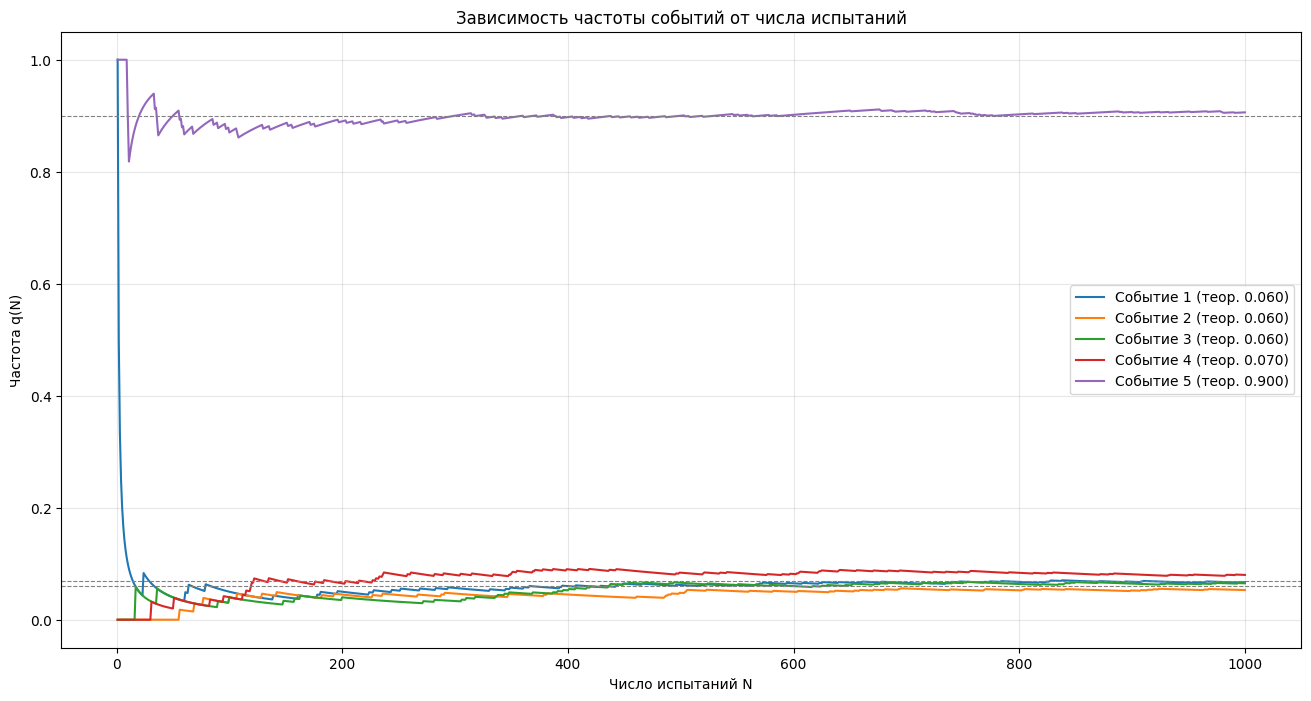

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

m, n = 5, 1000                      # размеры матрицы: 5 строк, 1000 столбцов
# Границы интервалов для каждой строки (вариант 4)
bounds = [
    (0.34, 0.40),   # строка 1
    (0.34, 0.40),   # строка 2
    (0.34, 0.40),   # строка 3
    (0.18, 0.25),   # строка 4
    (0.06, 0.96)    # строка 5
]

np.random.seed(42)                  # для воспроизводимости
A = np.random.rand(m, n)            # равномерное распределение [0, 1)
print("Первые 10 столбцов матрицы A (5×10):\n", A[:, :10], "\n")

def logzn(amin, amax, x):
    """Возвращает 1, если amin <= x < amax, иначе 0."""
    return 1 if amin <= x < amax else 0

B = np.zeros((m, n))
for i in range(m):
    amin, amax = bounds[i]
    for j in range(n):
        B[i, j] = logzn(amin, amax, A[i, j])

def fregp(v):
    """Частота = (число единиц) / (длина вектора)."""
    return sum(v) / len(v)

freq_full = [fregp(B[i, :]) for i in range(m)]
print("Частоты событий (N=1000):")
for i, f in enumerate(freq_full, 1):
    print(f"  Событие {i}: {f:.5f}")

cumsum = np.cumsum(B, axis=1)       # накопленные суммы по столбцам
N_vals = np.arange(1, n + 1)        # 1,2,...,1000
q_vals = cumsum / N_vals            # матрица 5×1000 частот для каждого N

# Построение графиков
plt.figure(figsize=(16, 8))
for i in range(m):
    plt.plot(N_vals, q_vals[i, :], label=f'Событие {i+1} (теор. {bounds[i][1]-bounds[i][0]:.3f})')
plt.axhline(y=0.06, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(y=0.07, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(y=0.90, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('Число испытаний N')
plt.ylabel('Частота q(N)')
plt.title('Зависимость частоты событий от числа испытаний')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

